# RQ1: Is higher adoption of aggregated security practices associated with measurable improvements in security outcomes? 



## Imports

In [89]:
import math
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from matplotlib import pyplot as plt

from settings import load_settings
from capstone import construct_final_dataset as fd

## Constants

In [27]:
SETTINGS = load_settings()

In [28]:
CONTROL_COLUMNS = [
    fd.C_REPOSITORY_CONTRIBUTIONS_COUNT,
    fd.C_REPOSITORY_SIZE_IN_KB,
    fd.C_REPOSITORY_AGE_IN_YEARS,
    fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS,
    fd.C_PACKAGE_DEPENDENCY_COUNT,
    fd.C_PACKAGE_TOTAL_DOWNLOADS,
]

## Loading Data

In [29]:
raw_df = pl.read_parquet(SETTINGS.research_question_1_dataset_path)

In [30]:
raw_df.head()

package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu
str,str,u32,i64,f64,i64,i64,i64,f64,i64,f64,f64
"""s3manifesto""","""machu-gwu/s3manifesto-project""",2,2648,1.6,266,1,242,2.3,0,null,null
"""deepteam""","""confident-ai/deepteam""",8,205459,1.03,0,23,88579,4.3,0,null,null
"""volosti-common""","""volosti/volosti-common""",5,23,3.6,1096,1,40,1.5,0,null,null
"""polyfit""","""dschmitz89/polyfit""",3,87339,5.41,354,2,370,2.0,10,null,null
"""tinyshare""","""yourusername/tinyshare""",3,20896,null,null,null,null,null,null,0.0,2.238036


In [31]:
raw_df.describe()

statistic,package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""46779""","""46779""",46779.0,46779.0,43086.0,43086.0,43151.0,43151.0,37422.0,37422.0,25262.0,25262.0
"""null_count""","""0""","""0""",0.0,0.0,3693.0,3693.0,3628.0,3628.0,9357.0,9357.0,21517.0,21517.0
"""mean""",null,null,5.620984,9.0404e6,5.512659,463.704336,12.472179,24371.912146,3.605903,7.707792,0.241445,5.203273
"""std""",null,null,7.413889,1.2423e8,3.450617,651.327571,31.736913,177510.051086,1.203484,3.775209,4.072507,16.031416
"""min""","""10xscale-agentflow""","""/edikedik""",0.0,5.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,2.0,6477.0,2.77,17.0,1.0,139.0,2.7,7.0,0.0,0.0
"""50%""",null,null,3.0,24113.0,5.12,154.0,4.0,701.0,3.4,10.0,0.0,0.595051
"""75%""",null,null,7.0,152344.0,7.69,678.0,11.0,5681.0,4.3,10.0,0.0,4.358773
"""max""","""zyte-parsers""","""~gb119/stoner-pythoncode""",268.0,9.4962e9,17.86,5005.0,472.0,1.0404261e7,11.5,10.0,217.992199,532.619235


## Inspecting Data

In [32]:
def plot_distributions(data: pl.DataFrame, columns: list[str]) -> None:

    pdf = data.to_pandas()

    ncols = math.ceil(len(columns) ** 0.5)
    nrows = math.ceil(len(columns) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 8))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(pdf[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)

    # remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

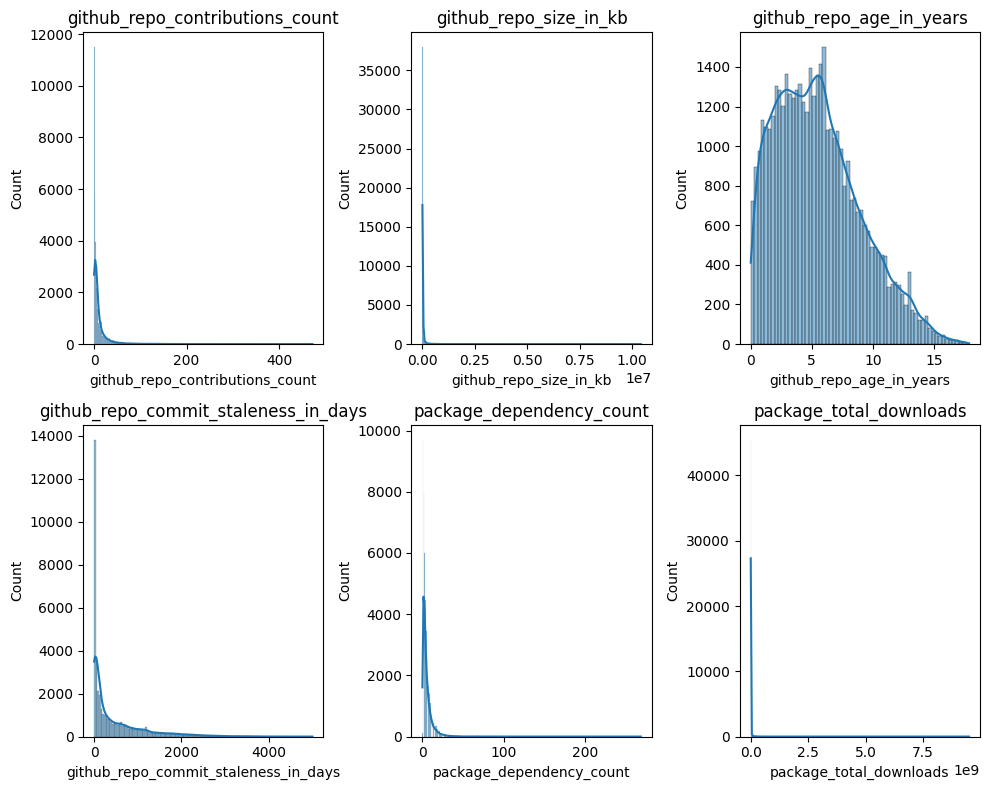

In [ ]:
plot_distributions(raw_df, CONTROL_COLUMNS)

## Transforming Data

In [66]:
df = (
    raw_df
        .drop_nulls()
        .drop_nans()
        .with_columns([pl.col(c).log1p() for c in CONTROL_COLUMNS])
)

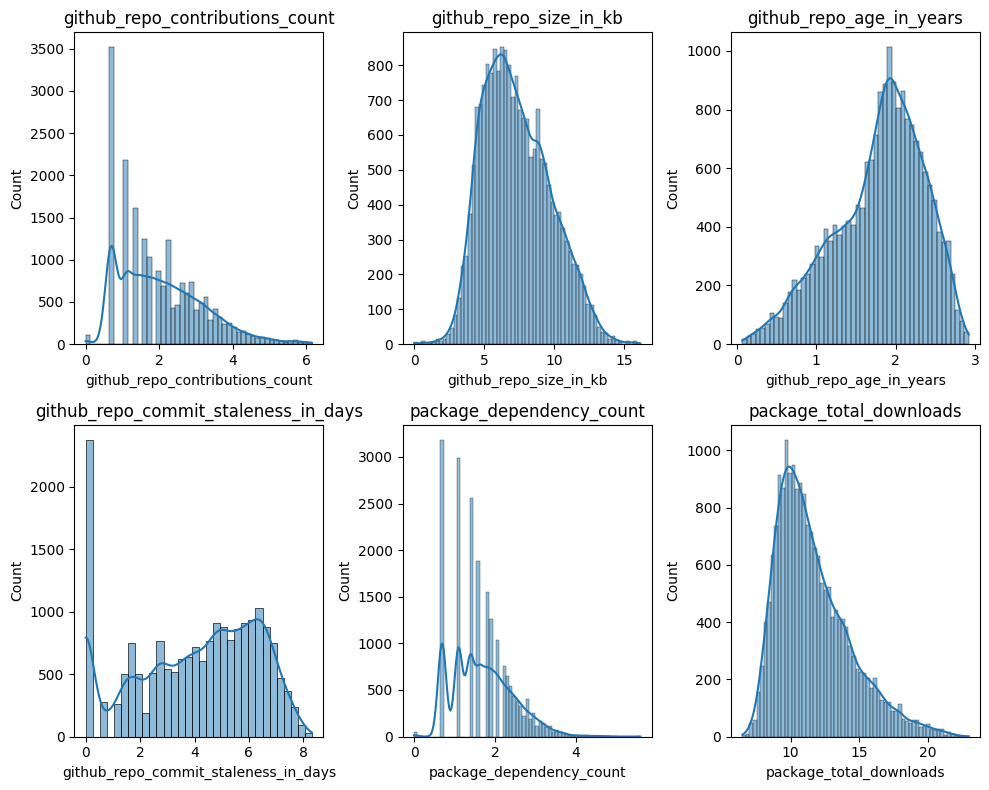

In [67]:
plot_distributions(df, CONTROL_COLUMNS)

## Baseline Models

In [76]:
p_df = df.to_pandas()
p_df.columns

Index(['package_name', 'github_repo', 'package_dependency_count',
       'package_total_downloads', 'github_repo_age_in_years',
       'github_repo_commit_staleness_in_days',
       'github_repo_contributions_count', 'github_repo_size_in_kb',
       'aggregated_score', 'vul_count', 'mttr', 'mttu'],
      dtype='object')

### Baseline: vul_count 

In [69]:
vul_count_formula = f"vul_count ~ aggregated_score + {' + '.join(CONTROL_COLUMNS)}"
vul_count_formula

'vul_count ~ aggregated_score + github_repo_contributions_count + github_repo_size_in_kb + github_repo_age_in_years + github_repo_commit_staleness_in_days + package_dependency_count + package_total_downloads'

In [ ]:
vul_count_poisson_model = smf.glm(formula=vul_count_formula, data=p_df, family=sm.families.Poisson()).fit()

In [ ]:
print(vul_count_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              vul_count   No. Observations:                19652
Model:                            GLM   Df Residuals:                    19644
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -61345.
Date:                Fri, 03 Apr 2026   Deviance:                       56482.
Time:                        06:36:45   Pearson chi2:                 3.67e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2524
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [ ]:
dispersion = vul_count_poisson_model.pearson_chi2 / vul_count_poisson_model.df_resid
print(f"Dispersion: {dispersion}")
if dispersion > 1.5:
    print("Evidence of overdispersion detected.")

Dispersion: 1.866551313686884
Evidence of overdispersion detected.


### Baseline: mttr 

In [77]:
mttr_formula = f"mttr ~ aggregated_score + {' + '.join(CONTROL_COLUMNS)}"
mttr_formula

'mttr ~ aggregated_score + github_repo_contributions_count + github_repo_size_in_kb + github_repo_age_in_years + github_repo_commit_staleness_in_days + package_dependency_count + package_total_downloads'

In [79]:
mttr_poisson_model = smf.glm(formula=mttr_formula, data=p_df, family=sm.families.Poisson()).fit()

In [80]:
print(mttr_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttr   No. Observations:                19652
Model:                            GLM   Df Residuals:                    19644
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -25788.
Date:                Fri, 03 Apr 2026   Deviance:                       49660.
Time:                        06:43:54   Pearson chi2:                 9.77e+05
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1161
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [81]:
dispersion = mttr_poisson_model.pearson_chi2 / mttr_poisson_model.df_resid
print(f"Dispersion: {dispersion}")
if dispersion > 1.5:
    print("Evidence of overdispersion detected.")

Dispersion: 49.732785457811566
Evidence of overdispersion detected.


### Baseline: mttu 

In [78]:
mttu_formula = f"mttu ~ aggregated_score + {' + '.join(CONTROL_COLUMNS)}"
mttu_formula

'mttu ~ aggregated_score + github_repo_contributions_count + github_repo_size_in_kb + github_repo_age_in_years + github_repo_commit_staleness_in_days + package_dependency_count + package_total_downloads'

In [82]:
mttu_poisson_model = smf.glm(formula=mttu_formula, data=p_df, family=sm.families.Poisson()).fit()

In [83]:
print(mttu_poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   mttu   No. Observations:                19652
Model:                            GLM   Df Residuals:                    19644
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.7555e+05
Date:                Fri, 03 Apr 2026   Deviance:                   3.1537e+05
Time:                        06:44:48   Pearson chi2:                 8.94e+05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4626
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [84]:
dispersion = mttu_poisson_model.pearson_chi2 / mttu_poisson_model.df_resid
print(f"Dispersion: {dispersion}")
if dispersion > 1.5:
    print("Evidence of overdispersion detected.")

Dispersion: 45.533559283828815
Evidence of overdispersion detected.


## Model

In [91]:
def fit_model(data: pd.DataFrame, target_variable: str):
    X = data[["aggregated_score", *CONTROL_COLUMNS]]
    X = sm.add_constant(X)
    y = data[target_variable]
    model = sm.NegativeBinomial(y, X).fit()
    return model
    

In [ ]:
vul_count_nb_model = fit_model(p_df, fd.T_VULNERABILITY_COUNT)
print(vul_count_nb_model.summary())

Optimization terminated successfully.
         Current function value: 2.944639
         Iterations: 18
         Function evaluations: 20
         Gradient evaluations: 20
                     NegativeBinomial Regression Results                      
Dep. Variable:              vul_count   No. Observations:                19652
Model:               NegativeBinomial   Df Residuals:                    19644
Method:                           MLE   Df Model:                            7
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.01606
Time:                        06:51:50   Log-Likelihood:                -57868.
converged:                       True   LL-Null:                       -58813.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [95]:
mttr_nb_model = fit_model(p_df, fd.T_MTTR)
print(mttr_nb_model.summary())

/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3471: RuntimeWarning: overflow encountered in scalar power
  da1 = -alpha**-2
/venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarni

         Current function value: nan
         Iterations: 2
         Function evaluations: 24
         Gradient evaluations: 24
                     NegativeBinomial Regression Results                      
Dep. Variable:                   mttr   No. Observations:                19652
Model:               NegativeBinomial   Df Residuals:                    19644
Method:                           MLE   Df Model:                            7
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                     nan
Time:                        06:52:57   Log-Likelihood:                    nan
converged:                      False   LL-Null:                       -4723.8
Covariance Type:            nonrobust   LLR p-value:                       nan
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                         

In [99]:
mttu_nb_model = fit_model(p_df, fd.T_MTTU)
print(mttu_nb_model.summary())

Optimization terminated successfully.
         Current function value: 2.314119
         Iterations: 34
         Function evaluations: 40
         Gradient evaluations: 40
                     NegativeBinomial Regression Results                      
Dep. Variable:                   mttu   No. Observations:                19652
Model:               NegativeBinomial   Df Residuals:                    19644
Method:                           MLE   Df Model:                            7
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                0.006282
Time:                        06:56:25   Log-Likelihood:                -45477.
converged:                       True   LL-Null:                       -45765.
Covariance Type:            nonrobust   LLR p-value:                5.960e-120
                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [104]:
stargazer = Stargazer([vul_count_nb_model, mttr_nb_model, mttu_nb_model])

stargazer.title("Regression Results")
stargazer.custom_columns(["Vul Count", "MTTR", "MTTU"], [1, 1, 1])
#stargazer.show_confidence_intervals(True)
stargazer